# Model B (conserved ∇²φ²) in d=1 — a composite-derivative vertex

**Showcases:** a **composite-derivative**, conservation-law vertex. Model B's flux form $g\,\partial_x^2(\phi^2)$ carries an overall $\partial_x^2 \to -q^2$ on the whole vertex, so the long-wavelength variance is conservation-suppressed.

$$\partial_t\phi = D\,\partial_x^2\phi - \mu\phi + g\,\partial_x^2(\phi^2) + \eta.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
THEORY = 'reaction_diffusion_conserved_1d'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)

────────────────────────────────────────────────────────────────────────
  1D conserved reaction-diffusion (derivative vertex)
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : phi (x∈ℝ^1) — conserved density
Response fields: phit
Parameters     :
    mu = 1.0  (positive)
    D = 2.0  (positive)
    g = 0.3  (real)
    T = 1.0  (positive)
Mean-field saddle (solved by the pipeline): phistar
Governing eqn  : (Dt + mu - D*Laplacian)*phi = g*Laplacian*phi^2
Suggested run  : k=2, max_ell=1

1D conserved (Model-B-type) reaction-diffusion with a derivative vertex —
the spatial v2 operator-IR test theory.

A scalar density with a *conserving* nonlinearity (a density-dependent /
porous-medium-type flux) plus a linear loss and white noise:

    ∂_t φ  =  D ∇²φ  -  μ φ  +  g ∇²(φ²)  +  η ,
    ⟨η(x,t) η(x',t')⟩  =  2T δ(x-x') δ(t-t').

Equivalently ``∂_t φ = ∇·[(D + 2gφ)∇φ] − μφ + η

"────────────────────────────────────────────────────────────────────────\n  1D conserved reaction-diffusion (derivative vertex)\n────────────────────────────────────────────────────────────────────────\nDomain         : spatial PDE · d=1 · boundary=infinite · initial=stationary\nFields         : phi (x∈ℝ^1) — conserved density\nResponse fields: phit\nParameters     :\n    mu = 1.0  (positive)\n    D = 2.0  (positive)\n    g = 0.3  (real)\n    T = 1.0  (positive)\nMean-field saddle (solved by the pipeline): phistar\nGoverning eqn  : (Dt + mu - D*Laplacian)*phi = g*Laplacian*phi^2\nSuggested run  : k=2, max_ell=1\n\n1D conserved (Model-B-type) reaction-diffusion with a derivative vertex —\nthe spatial v2 operator-IR test theory.\n\nA scalar density with a *conserving* nonlinearity (a density-dependent /\nporous-medium-type flux) plus a linear loss and white noise:\n\n    ∂_t φ  =  D ∇²φ  -  μ φ  +  g ∇²(φ²)  +  η ,\n    ⟨η(x,t) η(x',t')⟩  =  2T δ(x-x') δ(t-t').\n\nEquivalently ``∂_t φ =

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). The plot is the **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=1,
    external_fields=[('dphi', 1), ('dphi', 1)],
    parameters={'mu': 1.0, 'D': 2.0, 'g': 0.3, 'T': 1.0},
    chi_grid=(0.0, 8.0, 30),
    tau_max=0.0,
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   tau_step=0.5,                 # τ spacing (when tau_max > 0)
#   tau_grid=(-8.0, 8.0, 33),     # explicit τ grid (array | (lo,hi,n)); overrides tau_max/step
#   spatial_points=...,           # k≥3 spatial: (n_pts, k−1, 2) of explicit (x_j, τ_j) events
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   parallel=True,                # enable the parallel backend
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : '1D conserved reaction-diffusion (derivative vertex)'
k      : 2    max_ell : 1
fields : ['dphi']   spatial_dim : 1
diagrams (live): 3


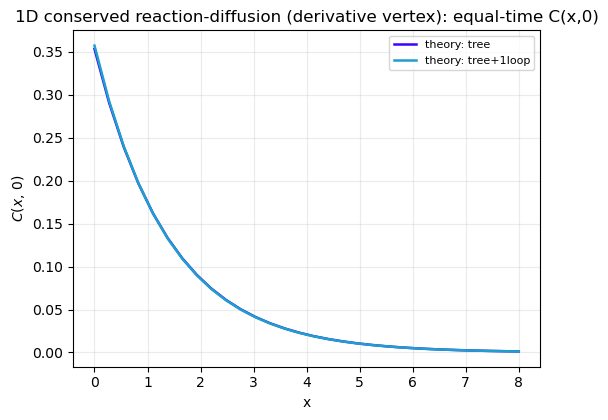

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct numerical integration of the SPDE — written from scratch, with no reference to the diagrammatics. Overlaying it on the pipeline curve is the validation.

theory C(0) = 0.3574   sim C(0) = 0.3560   (sim mean = -0.001)


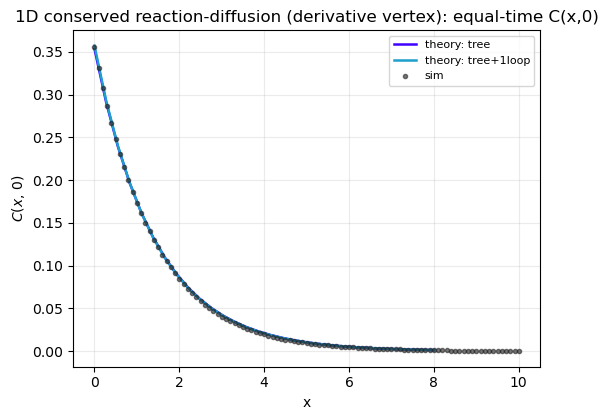

In [5]:
# Independent SPDE simulation (direct ETD1 integration) — NOT the
# pipeline.  Same physical parameters as the theory (read from the model).
from models.spatial_field_1d_sim import simulate, equal_time_correlator
fp = dd.parameters_from_model(model)
snaps, x_grid, meta = simulate(L=20.0, N=200, mu=fp['mu'], D=fp['D'], T=fp['T'],
                               g_lap=fp['g'],
                               n_steps=120000, burn_in=20000, record_every=20, seed=1)
mean = float(np.mean(snaps))      # ⟨φ⟩: ≈0 if symmetric, the excess velocity for KPZ
Cx = equal_time_correlator(snaps) - mean**2   # CONNECTED (the pipeline gives connected)
half = len(x_grid) // 2 + 1
sim = {'x': x_grid[:half], 'C': Cx[:half]}
mid = res['C_tau_x'].shape[0] // 2
print('theory C(0) = %.4f   sim C(0) = %.4f   (sim mean = %.3f)'
      % (np.real(res['C_tau_x'])[mid][0], sim['C'][0], mean))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

The composite ∇² vertex multiplies the form-factor by q², suppressing the loop correction at small momentum — the signature of a conserved order parameter. The SPDE simulation reproduces the suppressed variance.